In [1]:
import sys
from pathlib import Path

def find_root(marker='Data/train.csv'):
    for d in [Path.cwd().resolve(), *Path.cwd().resolve().parents]:
        if (d / marker).exists():
            return d
    raise FileNotFoundError('Không thấy repo root')
ROOT = find_root()
sys.path.append(str(ROOT / 'Modeling' / 'Code'))

In [2]:
import numpy as np, pandas as pd
from sklearn.metrics import average_precision_score
from eval_protocol import (prf, point_adjust, best_f1_threshold,
                           best_f1_prcurve, plot_pr_curve, time_split_per_kpi)
from preprocess import preprocess_all

In [3]:
train = pd.read_csv(ROOT / 'Data' / 'train.csv')
train.columns = ["timestamp", "value", "label", "kpi"]

In [4]:
train

,timestamp,value,label,kpi
0,1493568000,1.901639,0,02e99bd4f6cfb33f
1,1493568060,1.786885,0,02e99bd4f6cfb33f
2,1493568120,2.000000,0,02e99bd4f6cfb33f
3,1493568180,1.885246,0,02e99bd4f6cfb33f
4,1493568240,1.819672,0,02e99bd4f6cfb33f
...,...,...,...,...
2476310,1496895300,0.161922,1,88cf3a776ba00e7c
2476311,1496895360,0.162297,1,88cf3a776ba00e7c
2476312,1496895420,0.160597,1,88cf3a776ba00e7c
2476313,1496895480,0.160393,1,88cf3a776ba00e7c


In [5]:
def rolling_zscore(x, window, robust=False, eps=1e-9):
    """Score = |x_t - center| / scale; center/scale tính trên [t-w, t-1].
    shift(1) đảm bảo KHÔNG dùng x_t (tránh leakage + self-masking, §1.2)."""
    s = pd.Series(np.asarray(x, float)); past = s.shift(1)
    if robust:                                   # MAD-based (§1.3) — chậm hơn
        center = past.rolling(window).median()
        mad = past.rolling(window).apply(lambda a: np.median(np.abs(a-np.median(a))), raw=True)
        scale = mad * 1.4826
    else:                                        # mean/std — nhanh, vectorized
        center = past.rolling(window).mean(); scale = past.rolling(window).std()
    scale = scale.replace(0, np.nan).fillna(eps).clip(lower=eps)
    return ((s - center).abs() / scale).fillna(0.0).values   # warmup ->

In [6]:
from eval_protocol import evaluate_protocol

def run_kpi_zscore(gk, windows=(15,30,60,120), robust=False):
    # ĐỒNG BỘ dữ liệu với IF/ARIMA/STL: split -> preprocess_all (reindex đều + mask gap + segment)
    step = int(pd.Series(np.diff(np.sort(gk.timestamp.values))).mode().iloc[0])
    gk = time_split_per_kpi(gk, 0.6, 0.2)
    p  = (preprocess_all(gk, max_gap_points=5, norm_method='robust')
          .sort_values("timestamp").reset_index(drop=True))
    y   = p.label.values.astype(int); sp = p.split.values
    x   = p.value_filled.values.astype(float)     # z-score tự chuẩn hoá cục bộ -> value_filled hay value_norm đều như nhau
    seg = p.segment.values
    got = ~p.masked.values                         # loại điểm gap dài, giống 3 model kia
    mv, mt = (sp=="val") & got, (sp=="test") & got
    if y[mv].sum()==0 or y[mt].sum()==0:           # không đủ nhãn để tune/đánh giá
        return None

    def zscore_by_segment(w):                       # rolling TRONG từng segment -> KHÔNG bắc cầu qua gap
        s = np.full(len(x), np.nan)
        for sid in np.unique(seg):
            idx = np.where(seg == sid)[0]
            s[idx] = rolling_zscore(x[idx], w, robust=robust)
        return np.where(got, s, np.nan)             # điểm masked -> NaN (loại khỏi eval)

    best_w, best_ap, sc = None, -1, None            # tune window theo AP trên val
    for w in windows:
        s = zscore_by_segment(w)
        ap = average_precision_score(y[mv], s[mv])
        if ap > best_ap: best_ap, best_w, sc = ap, w, s

    te = (sp == "test")                              # lưới test ĐẦY ĐỦ (cả điểm không chấm)
    res = dict(window=best_w, ap_val=round(best_ap,3),
               ap_test=round(average_precision_score(y[mt], sc[mt]),3),
               n_anom_test=int(y[mt].sum()),
               y_test=y[mt], s_test=sc[mt],          # giữ lại để gộp vẽ PR curve
               timestamp=p.timestamp.values[mt])     # để xuất s
    proto = evaluate_protocol(y[mv], sc[mv], y[mt], sc[mt], step_s=step,
                              y_test_full=y[te], valid_test=got[te])   # fix TTD + P/R/F1 công bằng
    res["PW"], res["TTD"] = proto["PW"], proto["TTD"]
    res["roc"] = round(proto["ROC"], 3)
    return res

In [7]:
rows=[]; agg=dict(tp=0,fp=0,fn=0); skipped=[]
pk = []; SCORES = []                               # pk: vẽ macro PR | SCORES: xuất parquet
for kpi,g in train.groupby("kpi"):
    r = run_kpi_zscore(g, robust=False)
    if r is None: skipped.append(kpi[:8]); continue
    pk.append((r["y_test"], r["s_test"]))
    for k in ("tp","fp","fn"): agg[k]+=r["PW"][k]
    SCORES.append(pd.DataFrame({"kpi":kpi[:8], "timestamp":r["timestamp"],
                                "y":r["y_test"], "score":r["s_test"]}))
    rows.append(dict(kpi=kpi[:8], window=r["window"], ap_val=r["ap_val"], ap_test=r["ap_test"],
                     roc=r["roc"], prec=round(r["PW"]["precision"],3),
                     rec=round(r["PW"]["recall"],3), f1_pw=round(r["PW"]["fbeta"],3),
                     n_anom_test=r["n_anom_test"],
                     ttd_sec=r["TTD"]["ttd_sec_mean"],
                     detected=f'{r["TTD"]["detected_segments"]}/{r["TTD"]["total_segments"]}'))

res_df = pd.DataFrame(rows).sort_values("ap_test", ascending=False)
macro_ap = res_df["ap_test"].mean()              # AP chính thức = trung bình per-KPI (khớp tune per-KPI)

def micro(d):
    p=d["tp"]/(d["tp"]+d["fp"]) if d["tp"]+d["fp"] else 0
    r=d["tp"]/(d["tp"]+d["fn"]) if d["tp"]+d["fn"] else 0
    return p, r, (2*p*r/(p+r) if p+r else 0)

display(res_df)
print("Skipped (val/test thiếu anomaly):", skipped)
print(f"MACRO AP (trung bình per-KPI) = {macro_ap:.3f}   <-- số chính thức")
p,r,f = micro(agg); print(f"MICRO PW: P={p:.3f} R={r:.3f} F1={f:.3f}")
print(f"TTD trung bình (giây, theo threshold PW) = {res_df['ttd_sec'].mean():.1f}")
print(f"Tổng segment phát hiện được: {sum(int(d.split('/')[0]) for d in res_df['detected'])}"
      f"/{sum(int(d.split('/')[1]) for d in res_df['detected'])}")

,kpi,window,ap_val,ap_test,roc,prec,rec,f1_pw,n_anom_test,ttd_sec,detected
7,7c189dd3,60,0.472,0.431,0.691,0.750,0.381,0.505,63,64.615385,13/14
13,affb01ca,60,0.402,0.392,0.673,0.628,0.355,0.454,76,84.705882,17/18
12,a40b1df8,30,0.420,0.391,0.679,0.732,0.349,0.472,86,60.000000,18/20
9,8bef9af9,120,0.501,0.377,0.687,0.889,0.329,0.480,73,87.692308,13/15
5,40e25005,60,0.186,0.180,0.550,0.760,0.170,0.277,112,42.000000,10/15
6,71595dd7,60,0.143,0.126,0.615,0.611,0.096,0.167,228,60.000000,14/24
4,1c35dbf5,120,0.255,0.113,0.510,0.106,0.998,0.192,2709,0.000000,5/5
15,cff6d3c0,60,0.197,0.110,0.514,0.292,0.101,0.151,276,92.000000,15/33
16,da403e4e,15,0.232,0.084,0.758,0.009,1.000,0.018,238,0.000000,24/24
3,18fbb1d5,30,0.258,0.081,0.609,0.002,1.000,0.004,47,0.000000,6/6


Skipped (val/test thiếu anomaly): ['046ec29d', '54e8a140', '769894ba', '76f4550c', '8a20c229', '9bd90500', 'a5bf5d65', 'b3b2e6d1']
MACRO AP (trung bình per-KPI) = 0.148   <-- số chính thức
MICRO PW: P=0.041 R=0.376 F1=0.074
TTD trung bình (giây, theo threshold PW) = 128.7
Tổng segment phát hiện được: 175/547


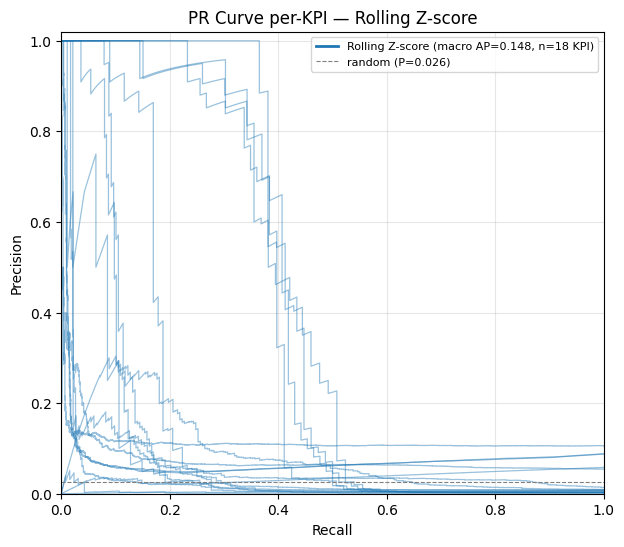

In [8]:
# PR curve per-KPI (macro) — số chính thức, khớp với việc tune threshold riêng từng KPI
# mỗi đường mờ = 1 KPI; legend ghi macro AP = trung bình AP per-KPI
plot_pr_curve({"Rolling Z-score": pk}, per_kpi=True,
              title="PR Curve per-KPI — Rolling Z-score");

In [9]:
res_df.to_json(ROOT / 'Modeling' / 'Stats' / 'RL' / 'rl_per_kpi_config.json',
               orient='records', indent=1)
ART = ROOT / 'Modeling' / 'Artifacts'; ART.mkdir(parents=True, exist_ok=True)
pd.concat(SCORES, ignore_index=True).to_parquet(ART / 'scores_RL.parquet', index=False)
print('Đã lưu:', len(res_df), 'KPI |', len(SCORES), 'KPI score ->', ART / 'scores_RL.parquet')

Đã lưu: 18 KPI | 18 KPI score -> C:\Projects\anomaly-detection-fundamentals\Modeling\Artifacts\scores_RL.parquet
